In [ ]:
# T03_01.py
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# 데이터 생성
cities = ['서울', '부산', '대구', '서울', '부산'] # ①
df = pd.DataFrame({'도시': cities}) # ②

# 레이블 인코딩
label_encoder = LabelEncoder() # ③
df['레이블인코딩'] = label_encoder.fit_transform(df['도시']) # ④

# 원-핫 인코딩
onehot_encoder = OneHotEncoder(sparse_output=False) # ⑤
onehot_result = onehot_encoder.fit_transform(df[['도시']]) # ⑥
onehot_df = pd.DataFrame(onehot_result, columns=onehot_encoder.get_feature_names_out(['도시'])) # ⑦

# 결과 병합 및 출력
df_combined = pd.concat([df[['도시', '레이블인코딩']], onehot_df], axis=1) # ⑧
print(df_combined) # ⑨

   도시  레이블인코딩  도시_대구  도시_부산  도시_서울
0  서울       2    0.0    0.0    1.0
1  부산       1    0.0    1.0    0.0
2  대구       0    1.0    0.0    0.0
3  서울       2    0.0    0.0    1.0
4  부산       1    0.0    1.0    0.0


In [ ]:
# T03_02.py
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter

# 극단적 불균형 데이터 생성
X, y = make_classification(n_samples=1000,
                           weights=[0.99, 0.01],
                           random_state=42) # ①
print(f"원본 데이터 클래스 분포: {Counter(y)}") # ②

# SMOTE 오버샘플링
smote = SMOTE(random_state=42) # ③
X_smote, y_smote = smote.fit_resample(X, y) # ④
print(f"SMOTE 적용 후 분포: {Counter(y_smote)}") # ⑤

원본 데이터 클래스 분포: Counter({np.int64(0): 987, np.int64(1): 13})
SMOTE 적용 후 분포: Counter({np.int64(0): 987, np.int64(1): 987})


In [ ]:
# T03_03.py
from sklearn.datasets import make_classification
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# 극단적 불균형 데이터 생성
X, y = make_classification(n_samples=1000,
                           weights=[0.99, 0.01],
                           random_state=42) # ①
print(f"원본 데이터 클래스 분포: {Counter(y)}") # ②

# 언더샘플링
under = RandomUnderSampler(random_state=42) # ③
X_under, y_under = under.fit_resample(X, y) # ④
print(f"언더샘플링 적용 후 분포: {Counter(y_under)}") # ⑤

원본 데이터 클래스 분포: Counter({np.int64(0): 987, np.int64(1): 13})
언더샘플링 적용 후 분포: Counter({np.int64(0): 13, np.int64(1): 13})


In [ ]:
# T03_04.py
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from collections import Counter

# 극단적 불균형 데이터 생성
X, y = make_classification(n_samples=1000,
                           weights=[0.99, 0.01],
                           random_state=42) # ①
print(f"원본 데이터 클래스 분포: {Counter(y)}") # ②

# 가중치 조정
model_weighted = LogisticRegression(class_weight='balanced',
                                    random_state=42).fit(X, y) # ③

원본 데이터 클래스 분포: Counter({np.int64(0): 987, np.int64(1): 13})


In [ ]:
# T03_05.py
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 생성
np.random.seed(42)
n = 300
df = pd.DataFrame({
  '상영시간': np.random.randint(80, 180, n),
  '제작비': np.random.randint(50, 500, n),
  '평점': np.random.uniform(5.0, 9.5, n),
  '배우수': np.random.randint(3, 15, n),
  '개봉관수': np.random.randint(500, 2000, n)
}) # ①

# 흥행 성공 여부(라벨 만들기)
df['흥행성공'] = ((df['평점'] > 7.5) & (df['개봉관수'] > 1000)
                & (df['제작비'] < 300)).astype(int) # ②

# 입력(X)과 정답(y) 분리
X = df[['상영시간', '제작비', '평점', '배우수', '개봉관수']] # ③
y = df['흥행성공'] # ④

# 학습용 / 테스트용 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # ⑤

# 표준화
scaler = StandardScaler() # ⑥
X_train = scaler.fit_transform(X_train) # ⑦
X_test = scaler.transform(X_test) # ⑧

# 로지스틱 회귀 학습
model = LogisticRegression() # ⑨
model.fit(X_train, y_train) # ⑩

# 정확도 확인
print("훈련 정확도:", model.score(X_train, y_train)) # ⑪
print("테스트 정확도:", model.score(X_test, y_test)) # ⑫

# 한 영화의 성공 확률 보기
proba = model.predict_proba(X_test[:1]) # ⑬
print(proba[0][1]) # ⑭

훈련 정확도: 0.9476190476190476
테스트 정확도: 0.8888888888888888
0.02480839073064884


In [ ]:
# T03_06.py
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 실제값과 예측값 정의
y_true = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
                   1, 0, 0, 1, 1, 0, 1, 0, 0, 1]) # ①
y_pred = np.array([1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
                   0, 0, 0, 1, 0, 1, 1, 0, 0, 1]) # ②

# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred) # ③
print(cm)

# sklearn 함수로 검증
print(f"{accuracy_score(y_true, y_pred):.3f}") # ④
print(f"{precision_score(y_true, y_pred):.3f}") # ⑤
print(f"{recall_score(y_true, y_pred):.3f}") # ⑥
print(f"{f1_score(y_true, y_pred):.3f}") # ⑦

[[6 4]
 [3 7]]
0.650
0.636
0.700
0.667


이탈 사용자 비율: 0.30
ROC AUC: 0.9123809523809523


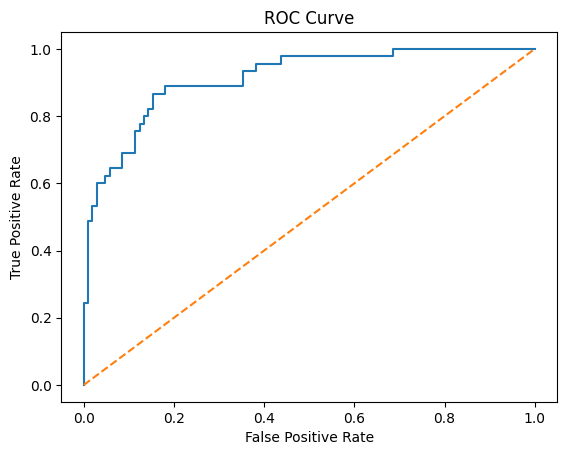

In [ ]:
# T03_07.py
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  accuracy_score, precision_score, recall_score,
  roc_curve, roc_auc_score,
  precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt

# 이탈 데이터 생성
np.random.seed(42)
X, y = make_classification(
  n_samples=500,
  weights=[0.7, 0.3],
  random_state=42
) # ①

print(f"이탈 사용자 비율: {y.mean():.2f}") # ②

# 학습용 / 테스트용 분리
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42, stratify=y
) # ③

# 로지스틱 회귀 학습
model = LogisticRegression(max_iter=1000) # ④
model.fit(X_train, y_train) # ⑤

# 확률 예측
y_proba = model.predict_proba(X_test)[:, 1] # ⑥

# ROC 곡선 계산
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba) # ⑦
roc_auc = roc_auc_score(y_test, y_proba) # ⑧
print(f"ROC AUC: {roc_auc}") # ⑨

plt.figure()
plt.plot(fpr, tpr) # ⑩
plt.plot([0, 1], [0, 1], linestyle='--') # ⑪
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Average Precision: 0.8449501666552977


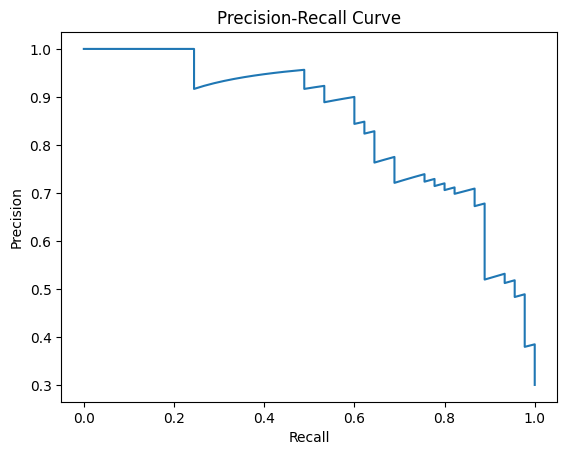

   임곗값    정확도    정밀도    재현율
0  0.3  0.840  0.706  0.800
1  0.5  0.833  0.727  0.711
2  0.7  0.853  0.829  0.644


In [ ]:
# T03_08.py
# PR 곡선 계산
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba) # ①
avg_precision = average_precision_score(y_test, y_proba) # ②
print(f"Average Precision: {avg_precision}") # ③
plt.figure()
plt.plot(recall, precision) # ④
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# 임곗값에 따라 분류 결과 비교
thresholds = [0.3, 0.5, 0.7] # ⑤
results = [] # ⑥
for t in thresholds: # ⑦
  y_pred = (y_proba >= t).astype(int) # ⑧

  results.append({
    "임곗값": t,
    "정확도": round(accuracy_score(y_test, y_pred), 3),
    "정밀도": round(precision_score(y_test, y_pred), 3),
    "재현율": round(recall_score(y_test, y_pred), 3)
  }) # ⑨

# 결과 출력
df = pd.DataFrame(results) # ⑩
print(df)

In [ ]:
# T03_09.py
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 데이터 만들기
np.random.seed(42)
n = 150
df = pd.DataFrame({
  '단맛': np.random.randint(0, 11, n),
  '카페인': np.random.randint(50, 200, n),
  '온도': np.random.choice([0, 1], n) # 0: 차가움, 1: 따뜻함
}) # ①

# 라벨 만들기
df['음료'] = 1 # ②
df.loc[(df['단맛'] < 4) & (df['카페인'] > 150), '음료'] = 0 # ③
df.loc[(df['단맛'] > 7) & (df['온도'] == 0), '음료'] = 2 # ④

# 입력(X)과 정답(y)
X = df[['단맛', '카페인', '온도']]
y = df['음료']

# 학습 / 테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42) # ⑤

# 지니 불순도 기준으로 트리 만들기
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=3) # ⑥
tree_gini.fit(X_train, y_train) # ⑦
print("지니 정확도:", tree_gini.score(X_test, y_test)) # ⑧
print("지니 노드 수:", tree_gini.tree_.node_count) # ⑨

# 엔트로피 기준으로 트리 만들기
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3) # ⑩
tree_entropy.fit(X_train, y_train) # ⑪
print("엔트로피 정확도:", tree_entropy.score(X_test, y_test)) # ⑫
print("엔트로피 노드 수:", tree_entropy.tree_.node_count) # ⑬

지니 정확도: 0.9736842105263158
지니 노드 수: 11
엔트로피 정확도: 1.0
엔트로피 노드 수: 9


In [ ]:
# T03_10.py
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 데이터 생성
X, y = make_classification(n_samples=300, n_features=5, random_state=42) # ①
df = pd.DataFrame(X, columns=['경력년수','학점','인터뷰','자격증','프로젝트']) # ②
df['합격'] = y # ③

# 학습/평가용 분리
X_train, X_test, y_train, y_test = train_test_split(
  df.drop('합격', axis=1), df['합격'], test_size=0.3, random_state=42
) # ④

# 과대적합 트리(제한 없음)
tree_big = DecisionTreeClassifier(random_state=42) # ⑤
tree_big.fit(X_train, y_train) # ⑥

# 깊이를 제한한 트리
tree_small = DecisionTreeClassifier(max_depth=5, random_state=42) # ⑦
tree_small.fit(X_train, y_train) # ⑧

# 결과 비교
print("제한 없음 - 훈련:", tree_big.score(X_train, y_train),
      "테스트:", tree_big.score(X_test, y_test)) # ⑨
print("깊이 제한 - 훈련:", tree_small.score(X_train, y_train),
      "테스트:", tree_small.score(X_test, y_test)) # ⑩

제한 없음 - 훈련: 1.0 테스트: 0.9
깊이 제한 - 훈련: 0.9904761904761905 테스트: 0.9222222222222223


In [ ]:
# T03_11.py
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text

# 대출 승인 데이터 만들기
X, y = make_classification(n_samples=400,
n_features=8, random_state=42) # ①
features = ['연소득', '신용점수', '고용년수', '부채비율',
            '대출금액', '담보가치', '연체횟수', '기존대출수'] # ②
df = pd.DataFrame(X, columns=features) # ③
df['승인'] = y # ④

# 학습 / 테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
  df[features], df['승인'], test_size=0.3, random_state=42
) # ⑤

# 결정트리 학습
tree = DecisionTreeClassifier(max_depth=4,
                              min_samples_leaf=10, random_state=42) # ⑥
tree.fit(X_train, y_train) # ⑦

print("훈련 정확도:", tree.score(X_train, y_train)) # ⑧
print("테스트 정확도:", tree.score(X_test, y_test)) # ⑨

# 중요한 변수 보기
importance = pd.DataFrame({
  '변수': features,
  '중요도': tree.feature_importances_
}).sort_values('중요도', ascending=False) # ⑩

print("중요한 변수 Top 5")
print(importance.head()) # ⑪

# 트리 규칙 일부 출력
print("결정트리 규칙 일부")
rules = export_text(tree, feature_names=features) # ⑫
print(rules[:400]) # ⑬

훈련 정확도: 0.95
테스트 정확도: 0.8833333333333333
중요한 변수 Top 5
     변수       중요도
2  고용년수  0.978946
0   연소득  0.013236
5  담보가치  0.007818
1  신용점수  0.000000
3  부채비율  0.000000
결정트리 규칙 일부
|--- 고용년수 <= -0.05
|   |--- 고용년수 <= -0.21
|   |   |--- 담보가치 <= -0.92
|   |   |   |--- 연소득 <= -0.08
|   |   |   |   |--- class: 0
|   |   |   |--- 연소득 >  -0.08
|   |   |   |   |--- class: 0
|   |   |--- 담보가치 >  -0.92
|   |   |   |--- 담보가치 <= 0.03
|   |   |   |   |--- class: 0
|   |   |   |--- 담보가치 >  0.03
|   |   |   |   |--- class: 0
|   |--- 고용년수 >  -0.21
|   |   |--- class: 0
|--- 고용년수 >  -0.05



In [ ]:
# T03_12.py
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 분류 데이터 생성
X, y = make_classification(
  n_samples=1000,
  n_features=20,
  random_state=42
) # ①

# 학습 / 테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42
) # ②

# 랜덤 포레스트 모델 생성
rf = RandomForestClassifier(
  n_estimators=100,
  max_features='sqrt',
  oob_score=True,
  random_state=42,
  n_jobs=-1
) # ③

# 학습
rf.fit(X_train, y_train) # ④

# 예측
y_pred = rf.predict(X_test) # ⑤

# 성능 평가
print("테스트 정확도:", accuracy_score(y_test, y_pred)) # ⑥
print("OOB 정확도:", rf.oob_score_) # ⑦

# 개별 트리 확인
print("총 트리 개수:", len(rf.estimators_)) # ⑧
print("첫 번째 트리 깊이:", rf.estimators_[0].tree_.max_depth) # ⑨

테스트 정확도: 0.8566666666666667
OOB 정확도: 0.9014285714285715
총 트리 개수: 100
첫 번째 트리 깊이: 10


In [ ]:
# T03_13.py
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# 유방암 데이터 로드
data = load_breast_cancer() # ①
X, y = data.data, data.target # ②

# 훈련 / 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42, stratify=y
) # ③

# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42) # ④
ada.fit(X_train, y_train) # ⑤
ada_acc = ada.score(X_test, y_test) # ⑥
print("AdaBoost 정확도:", round(ada_acc, 4))

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42) # ⑦
gb.fit(X_train, y_train) # ⑧
gb_acc = gb.score(X_test, y_test) # ⑨
print("GradientBoosting 정확도:", round(gb_acc, 4))

# XGBoost + Early Stopping
xgb = XGBClassifier(
  n_estimators=500,
  learning_rate=0.1,
  random_state=42,
  eval_metric='logloss',
  early_stopping_rounds=10
) # ⑩

xgb.fit(
 X_train, y_train,
 eval_set=[(X_test, y_test)],
 verbose=False
) # ⑪

xgb_acc = xgb.score(X_test, y_test) # ⑫
print("XGBoost 정확도:", round(xgb_acc, 4))
print("최적 트리 개수:", xgb.best_iteration) # ⑬

AdaBoost 정확도: 0.9532
GradientBoosting 정확도: 0.9474
XGBoost 정확도: 0.9532
최적 트리 개수: 84


In [ ]:
# T03_14.py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 유방암 데이터 로드
data = load_breast_cancer()
X, y = data.data, data.target

# 훈련 / 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42, stratify=y
)

# 개별 모델 정의
estimators = [
  ('lr', LogisticRegression(max_iter=10000)),
  ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
  ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
] # ①

# 소프트 보팅(확률 평균)
voting_clf = VotingClassifier(
  estimators=estimators,
  voting='soft' # ②
)

# 학습 및 예측
voting_clf.fit(X_train, y_train) # ③
y_pred = voting_clf.predict(X_test)
accuracy = voting_clf.score(X_test, y_test)
print(f"Voting Classifier 정확도: {accuracy:.4f}")

Voting Classifier 정확도: 0.9591


In [ ]:
# T03_15.py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 유방암 데이터 로드
data = load_breast_cancer()
X, y = data.data, data.target

# 훈련 / 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42, stratify=y
)

# 1단계 모델 정의
estimators = [
  ('rf', RandomForestClassifier(n_estimators=100, random_state=42)), # ①
  ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# 스태킹 모델 생성(메타 모델: LogisticRegression)
stacking_clf = StackingClassifier(
 estimators=estimators, # ②
 final_estimator=LogisticRegression(), # ③
 cv=5 # ④
)

# 학습 및 예측
stacking_clf.fit(X_train, y_train) # ⑤
y_pred = stacking_clf.predict(X_test)
print(f"Stacking 정확도: {stacking_clf.score(X_test, y_test):.4f}")

Stacking 정확도: 0.9474


In [ ]:
# T03_16.py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 유방암 데이터 로드
data = load_breast_cancer()
X, y = data.data, data.target

# 훈련 / 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42, stratify=y
)

# 각 모델 학습
model_lr = LogisticRegression(max_iter=10000)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
model_gb.fit(X_train, y_train)

# 각 모델의 예측 확률
pred_lr = model_lr.predict_proba(X_test)[:, 1] # ①
pred_rf = model_rf.predict_proba(X_test)[:, 1]
pred_gb = model_gb.predict_proba(X_test)[:, 1]

# 가중 평균(가중치 합 = 1)
weight_lr = 0.2 # ②
weight_rf = 0.3
weight_gb = 0.5
final_proba = (weight_lr * pred_lr +
weight_rf * pred_rf +
weight_gb * pred_gb) # ③

# 최종 예측(0.5 기준)
final_pred = (final_proba >= 0.5).astype(int) # ④
accuracy_manual = (final_pred == y_test).mean()
print(f"Blending 정확도: {accuracy_manual:.4f}")

Blending 정확도: 0.9532


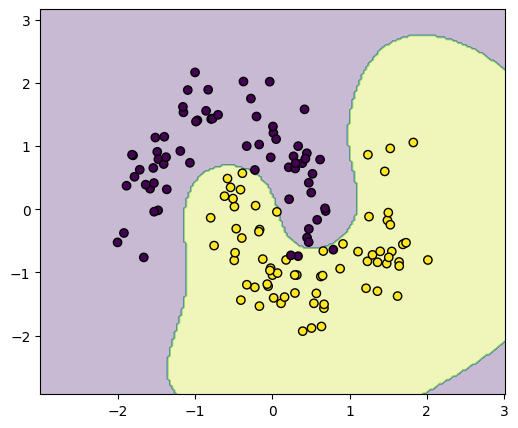

In [ ]:
# T03_17.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 반달 모양 데이터 생성
X, y = make_moons(n_samples=200, noise=0.2, random_state=42) # ①

# 학습 / 테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # ②

# 표준화(SVM은 거리 기반이므로 필수)
scaler = StandardScaler() # ③
X_train = scaler.fit_transform(X_train) # ④
X_test = scaler.transform(X_test) # ⑤

# RBF 커널 SVM 생성 및 학습
model = SVC(kernel='rbf', gamma=1.0, C=1.0) # ⑥
model.fit(X_train, y_train) # ⑦

# 분류 경계 시각화
xx, yy = np.meshgrid(
  np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 200),
  np.linspace(X_train[:,1].min()-1, X_train[:,1].max()+1, 200)
) # ⑧

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) # ⑨
Z = Z.reshape(xx.shape) # ⑩

plt.figure(figsize=(6,5)) # ⑪
plt.contourf(xx, yy, Z, alpha=0.3) # ⑫
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor='k') # ⑬
plt.show()

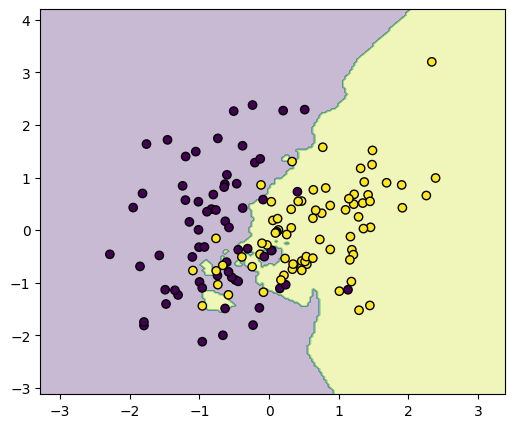

In [ ]:
# T03_18.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# 반달 모양 데이터 생성
X, y = make_classification(
  n_samples=200, n_features=2, n_informative=2,
  n_redundant=0, n_clusters_per_class=1, random_state=42
) # ①

# 학습 / 테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42
) # ②

# 표준화
scaler = StandardScaler() # ③
X_train = scaler.fit_transform(X_train) # ④
X_test = scaler.transform(X_test) # ⑤

# KNN 모델 생성
model = KNeighborsClassifier(n_neighbors=5, metric='euclidean') # ⑥
model.fit(X_train, y_train) # ⑦

# 분류 경계 시각화용 격자 생성
xx, yy = np.meshgrid(
  np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 200),
  np.linspace(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, 200)
) # ⑧

# 각 격자점에 대해 클래스 예측
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) # ⑨
Z = Z.reshape(xx.shape) # ⑩

# 결정경계 시각화
plt.figure(figsize=(6, 5)) # ⑪
plt.contourf(xx, yy, Z, alpha=0.3) # ⑫
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k') # ⑬
plt.show()

In [ ]:
# Q03_01.py
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 데이터 로드
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='class') # ①

# 타겟 클래스 이름 확인
print(f"클래스 이름: {cancer.target_names}") # ['malignant' 'benign'] # ②

# 타겟 데이터 분포 확인(클래스 불균형 여부 파악)
print(y.value_counts()) # ③

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # ④

클래스 이름: ['malignant' 'benign']
class
1    357
0    212
Name: count, dtype: int64


In [ ]:
# Q03_02.py
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 모델 생성
log_reg = LogisticRegression(max_iter=10000) # ①
dt_clf = DecisionTreeClassifier(random_state=42) # ②

# 모델 학습
log_reg.fit(X_train, y_train) # ③
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Q03_03.py
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# 예측(Class 예측 및 확률 예측)
pred_log = log_reg.predict(X_test) # ①
proba_log = log_reg.predict_proba(X_test)[:, 1] # ②
pred_dt = dt_clf.predict(X_test)
proba_dt = dt_clf.predict_proba(X_test)[:, 1]

# 평가
print(f"[Logistic Regression] Accuracy: {accuracy_score(y_test, pred_log):.4f}, ROCAUC: {roc_auc_score(y_test, proba_log):.4f}") # ③
print(f"[Decision Tree] Accuracy: {accuracy_score(y_test, pred_dt):.4f}, ROC-AUC:{roc_auc_score(y_test, proba_dt):.4f}")

# 오차 행렬 확인(로지스틱 회귀 기준)
print("\n[Confusion Matrix - Logistic Regression]")
print(confusion_matrix(y_test, pred_log)) # ④

[Logistic Regression] Accuracy: 0.9649, ROCAUC: 0.9954
[Decision Tree] Accuracy: 0.9123, ROC-AUC:0.9157

[Confusion Matrix - Logistic Regression]
[[39  3]
 [ 1 71]]
